## 6. Putting it all together
(Date - 7/Apr/2026)

We will put everything that we did from 20.ipynb to 27.ipynb into a single 27.ipynb file...

In [1]:
import torch
import matplotlib.pyplot as plt
from torch import nn
from pathlib import Path

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using Device {device}")

Using Device cpu


### 6.1 Getting data ready

In [3]:
# Create some data using the linear regression formula of y = mx + c
weight = 0.4
bias = 0.6

# Create range values
start = 0
end = 1
step = 0.02

# Create X and Y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1) # Without unsqueeze, error will pop out
Y = weight * X + bias
X[:10], Y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.6000],
         [0.6080],
         [0.6160],
         [0.6240],
         [0.6320],
         [0.6400],
         [0.6480],
         [0.6560],
         [0.6640],
         [0.6720]]))

In [4]:
# Split the data
train_split = int(0.6 * len(X))
X_train, Y_train = X[:train_split], Y[:train_split]
X_test, Y_test = X[train_split:], Y[train_split:]
len(X_train), len(Y_train), len(X_test), len(Y_test)

(30, 30, 20, 20)

In [5]:
# Plot the data
def plot_predictions(train_data=X_train, 
                     train_labels=Y_train, 
                     test_data=X_test, 
                     test_labels=Y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  #               X            Y
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  #               X           Y
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14})

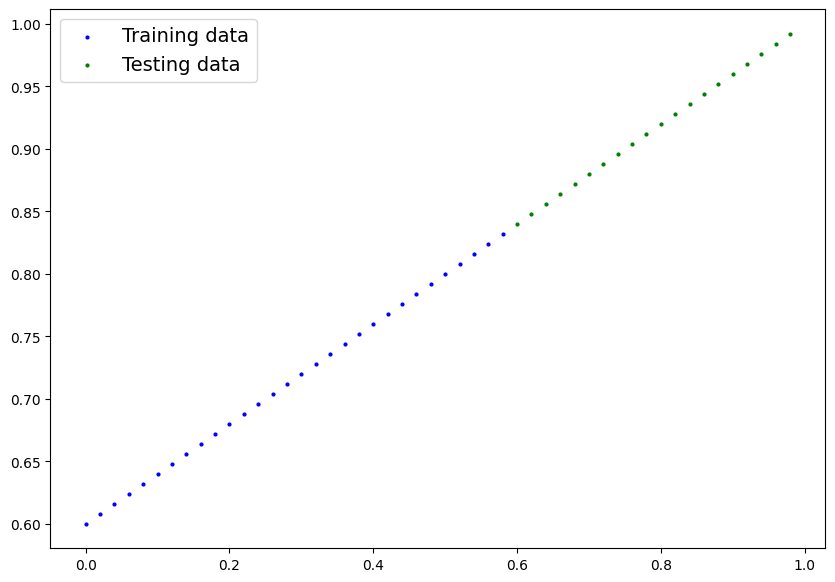

In [6]:
plot_predictions()

### 6.2 Building a PyTorch linear model

In [7]:
# Create a linear model by subclassing nn.Module
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Use nn.Linear() for creating the model parameters
        self.linear_layer = nn.Linear(in_features=1,
                                      out_features=1,
                                      bias=True) # Bias is set true by default
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)
    
# Set the manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModel()
model_1, model_1.state_dict()

(LinearRegressionModel(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

### 6.3 Training our model

In [8]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup our optimizer
optimizer = torch.optim.SGD(params = model_1.parameters(), 
                            lr = 0.001)

In [9]:
# Let's write a training loop
epochs = 5000

for epoch in range(epochs):
    model_1.train()

    Y_pred = model_1(X_train)
    train_loss = loss_fn(Y_pred, Y_train)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

print(f"Training Loss : {train_loss} -> Pretty god")

Training Loss : 0.0004970511072315276 -> Pretty god


### 6.4 Testing our model (Making predictions and evaluating)

Test_loss : 0.0001394808350596577 -> Pretty good


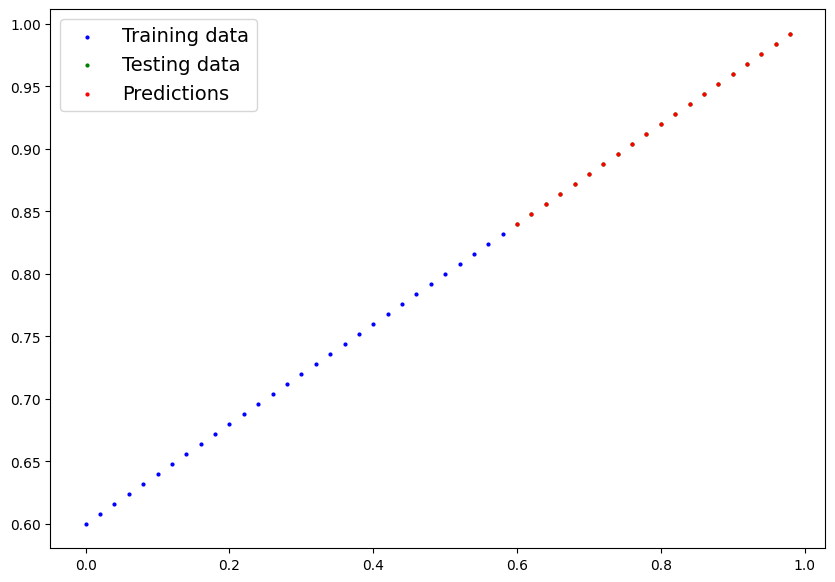

In [10]:
# Testing
model_1.eval()
with torch.inference_mode():
    test_pred = model_1(X_test)                  # Making predictions
    test_loss = loss_fn(test_pred, Y_test)       # Calculating the test loss

plot_predictions(predictions=test_pred)          # Visualizing the predictions
print(f"Test_loss : {test_loss} -> Pretty good") # Evaluating our model

### 6.5 Saving and loading our model (28.ipynb)

In [11]:
# Saving our model
torch.save(obj=model_1.state_dict(),
           f = "models/model_1_ipynb_27")

In [13]:
# Loading our model
loaded_model_2 = LinearRegressionModel()
raw_data_model_2 = torch.load(f="models/model_ipynb_21")
loaded_model_2.load_state_dict(raw_data_model_2)

<All keys matched successfully>

## **A Godly Summary!**
Date - 8/Apr/2026

---
<details>
(Date - 8/Apr/2026)
<summary><h3 style="display:inline;"><b>0. Introduction</b></h3></summary>

We will plot a bunch of points on a graph. Our model's task is to fit a line that best represents the relationship between x and y (Or, in other words, our model's task is to find the weight(w) and bias(b) values that are closest to the real ones).<br>

For this, we will first train our model, and then test it. This process is called [**Linear Regression**](https://www.geeksforgeeks.org/machine-learning/ml-linear-regression/).<br>

After training and testing our model, we will save it so that we can load it later (Maybe on another device or online).
</details>




<details>
(Date - 8/Apr/2026)
<summary><h3 style="display:inline;"><b>1. Getting data ready</b></h3></summary>
<br>
In this section, we will prepare our data.<br>

What do we need as our data?
The **x and y coordinates** of our points!

<details>
<summary><h4 style="display:inline; color:cyan"><b>1.1 Set weight and bias</b></h4></summary>
<br>

The linear regression formula is:<br>
_**y = xW^T + b**_
<pre>
where:
    y = dependent value (in our case, the y coordinate)
    x = input vector
    W = weight matrix (it also controls the slope of line)
    b = bias (increasing the bias shifts the line up, decreasing it shifts the line down. You can see that our points start from the y-coordinate 0.60... It's because we have set bias = 0.6)

So we set the values of weight and bias.
</pre>
<br>
</details>

<details>
<summary><h4 style="display:inline; color:cyan"><b>1.2 Get the x and y coordinates ready</b></h4></summary>
<br>

We will set the x coordinates by using [torch.arange()](https://docs.pytorch.org/docs/stable/generated/torch.arange.html) method.<br><br>
The range is from 0 to 1, and the gap between each value is 0.02, so the total no. of values is 1/0.02 = 50 values.<br>
After getting the x-coordinates, we will get the y-coordinates by using the linear regression formula (as mentioned above).
<br>
</details>

<details>
<summary><h4 style="display:inline; color:cyan"><b>1.3 Splitting the data</b></h4></summary>
<br>

We will split the data - 60% for training and 40% for testing. You may use the ratio - 4 : 1 as well (80% for training and 20% for testing. Also it is the most popular ratio to split the training and testing data).
<br>
</details>
</details>




<details>
(Date - 8/Apr/2026)
<summary><h3 style="display:inline;"><b>2. Building our model</b></h3></summary>

There is a class named Module in nn (that we imported from torch).

So we will create a new class - LinearRegressionModel - as a subclass of [**nn.Module**](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html).

---
<details>
<summary><h4 style="display:inline; color:cyan"><b>2.1 def __ init __(self)</b></h4></summary>

This initializes everything that is written under it. Normally, it is used to initialize variables (like an employee's salary, his/her name, his/her rank, etc.)
</details>
<details>

<summary><h4 style="display:inline; color:cyan"><b>2.2 super().__ init __()</b></h4></summary>

This initializes everything of the parent class (In this case, nn.Module. This class has internal dictionaries like parameters, modules, buffers, etc. So it initializes all of them).
</details>
<details>
<summary><h4 style="display:inline; color:cyan"><b>2.3 self.linear_layer = nn.Linear(in_features = 1, out_features = 1, bias = True)</b></h4></summary>
(Date - 9/Apr/2026)

Initially, we used the [**torch.nn.Parameters()**](https://www.geeksforgeeks.org/deep-learning/understanding-torchnnparameter/) method to create every parameter ourselves. Now we are using [**nn.Linear()**](https://www.geeksforgeeks.org/machine-learning/multi-dimensional-inputs-in-pytorch-linear-method-in-python/) method to automatically create them (without writing too much).

_Explanation for nn.Linear():_

Internally, nn.Linear() is of the form - _**y = xW^T + b**_<br>
So when we initialize it, it automatically (randomly) sets the weight and bias values (So that we don't need to make each parameter by hand).<br>
In our case, it set - bias = 0.8300, and weight = 0.7645 (when torch.manual_seed is set 42)
</details>
<details>

<summary><h4 style="display:inline; color:cyan"><b>2.4 forward(self, X)</b></h></summary>

(Date - 10/Apr/2026)

reference link - https://www.geeksforgeeks.org/deep-learning/understanding-the-forward-function-output-in-pytorch/

This method is essential for the flow (Input -> Processing -> Output) of data through the hidden layers of a neural network. What this method actually does is that it takes the input, processes it through the network's layer, and returns the output.

_**Note:**_ The forward method defines the computation of the model (how input is transformed into output). It does not handle gradient computation directly.

Question: Why don't we write `MyModel.forward(x)` instead of `MyModel(x)`?<br>

Answer: This is because when you write:<br>
```py
MyModel(x)
```
You are not calling:
```py
forward(x)
```
You are calling:
```py
MyModel.__ call __(x)
```
Internally, this call method does a bunch of things along with the forward pass.

Other things __ call __ does are:<br>
1. Hooks (You can attach functions that run before forward, and after forward)

2. Autograd tracking (When forward(x) runs, PyTorch builds a computational graph where every operation is recorded. So when you use loss.backward(), PyTorch knows that these results came from this output -> trace back -> calculate gradients)

3. Mode handling (train/eval) [Things like model.train() and model.eval() affect layers like Dropout and BatchNorm. __ call __ ensures that the correct behaviour is used during forward()]

Note:<br>
Even if you write model.forward(x), the results will be same.
</details>
</details>





<details>
<summary><h3 style="display:inline;"><b>3. Training our model</b></h3></summary>
(Date - 11/Apr/2026)
<details>
<summary><h4 style="display:inline; color:cyan"><b>3.1 Initializing</b></h4></summary>
<details>
<summary><h5 style="display:inline; color:yellow;"><b>3.1.1 nn.L1Loss()</b></h5></summary>

The loss function tells us how wrong our model predictions are. The lower the loss value is, the better our model's predictions.

There are several types of Loss functions in PyTorch. Some are:

**L1Loss:** |predicted value - true value| -> Absolute difference <br>
**L2Loss:** (predicted value - true value)^2 -> Punishes big mistakes more<br>
**CrossEntropyLoss:** Used for [classification](https://www.learnpytorch.io/02_pytorch_classification/) -> Tells you how wrong your predicted probabilities are.
</details>

<details>
<summary><h5 style="display:inline; color:yellow;"><b>3.1.2 torch.optim.SGD()</b></h5></summary>

SGD = [Stochastic Gradient Descent](https://www.geeksforgeeks.org/machine-learning/ml-stochastic-gradient-descent-sgd/)

SGD uses gradients (calculated by loss.backward()) to update the weights in the direction that reduces the loss.

_Simple idea:_ The model updates its parameters slightly in the direction opposite to the gradient (which points toward increasing loss), so that the loss decreases over time. 

lr(learning rate) : To choose how big the step should be. If the step is too big, then you will never get a precise ideal value. If the step is too small, then the learning will take forever. Therefore, the step should neither be too big, nor be too small. In our case : lr = 0.001. Smaller learning rate = More training time.
</details>
</details>


<details>
(Date - 12/Apr/2026)
<summary><h4 style = "display:inline; color:cyan"><b>3.2 Training Loop</b></h4></summary>
<details>
<summary><h5 style = "display:inline; color:yellow;"><b>3.2.1 model.train()</b></h5></summary>

reference link - https://www.geeksforgeeks.org/deep-learning/what-does-model-train-do-in-pytorch/

It sets the model into training mode. It activates the following things:
<details>
<summary><h5 style = "display:inline; color:green"><b>3.2.1.1 Dropout</b></h5></summary>

link - https://www.geeksforgeeks.org/python/how-to-use-torch-nn-dropout-method-in-python-pytorch/

Function : To randomly turn off some neurons (i.e. to multiply their output with 0)

Why randomly turn off some neurons?<br>
Imagine you have three neurons:<br>
Neuron A<br>
Neuron B<br>
Neuron C<br>

Now if Neuron A detects the pattern, then the whole network will be fully dependent on it. So during testing, if A is slightly wrong (i.e. if A performs poorly on new data), then the model's performance drops significantly. But if we randomly turn off this neuron, then the model has to stop and think (i.e. the model is forced to rely on other neurons to make correct predictions). Because of this, the model will not be dependent on a single (or a few) neurons.

**Conclusion:** This helps the model generalize better to unseen data instead of memorizing the training data.
</details>
<details>
<summary><h5 style = "display:inline; color:green"><b>3.2.1.2 BatchNorm</b></h5></summary>

link - https://www.geeksforgeeks.org/deep-learning/batch-normalization-implementation-in-pytorch/

**Intuition:**

While training a model, some values are big while some are small (i.e. the numbers get wildly changed while training). This sudden change in the size of values **creates instability** (Because layers keep adjusting which messes up the next layer which messes up the next). <br>
So here comes Batchnorm! What it does is simple : It takes the values and makes them centered (i.e. neither too large, nor too small - **balanced around a common level**), and makes things simpler (Makes the values simpler and easier for the next layer to learn). 

So **It centers the values around a common level and keeps their spread controlled.**

Example:

You have the following data (Output values):<br>
[500, 1200, -300, 80]

Batchnorm will convert it into something like:
[ -1, 0.5, -0.8, 1.2 ]

Question : Is the information not being lost?
Answer : No. This is because after Batchnorm normalizes the values, it allows the model to adjust them accordingly. 

Example:

What if the model actually needs values like:<br>
[ 10, 20, 30 ]

or shifted like:<br>
[ 5, 6, 7 ]

So Batchnorm allows the model to scale and shift the values if needed.
</details>
</details>

<details>
<summary><h5 style = "display:inline; color:yellow;"><b>3.2.2 Model_1(X_train) or Model_1.forward(X_train)</b></h5></summary>

This calls the forward method (inside the Model_1 class) directly. This method is used to pass your input data through the layers of your network.

(The forward method is discussed in much detail above at 2.4 forward(self, X).)
</details>
<details>
<summary><h5 style = "display:inline; color:yellow;"><b>3.2.3 loss_fn(Y_pred, Y_test)</b></h5></summary>

Compares each value of the matrices Y_pred and Y_test, then returns the absolute difference between them (Absolute difference because we are using L1loss).

For example:

if a value of Y_pred is 3, and the same corresponding value in Y_test is 5, then:<br>
Absolute difference = |3 - 5| = |-2| = 2

(The loss function is discussed in much detail above.)
</details>
<details>
<summary><h5 style = "display:inline; color:yellow;"><b>3.2.4 optimizer.zero_grad()</b></h5></summary>

reference link - https://www.geeksforgeeks.org/deep-learning/why-do-we-need-to-call-zerograd-in-pytorch/

When you do [loss.backward()](https://www.geeksforgeeks.org/machine-learning/backpropagation-in-neural-network/), PyTorch calculates gradients (A gradient is a measure of the steepness, slope, or rate of change of a value) and stores them. But:<br>
The gradients don't get overwrite, the get added to the older ones.

Example:

You do loss backward and get:<br>

```python
loss.backward()
gradient = 2
```
Next iteration (without zero_grad()):
```python
loss.backward()
gradient = 2 + 3 = 5
```

So the gradient is wrong and that's a problem. That's why torch.zero_grad() is used. It clears up the old gradients. Which means it will set:
```py
gradient = 0
```
after you call it.

Question : Why didn't the makers of PyTorch make this clearing up of old gradients automatic? Why do we have to write it (torch.zero_grad())?

Answer: Because the developers of PyTorch didn't want to hide anything. If they make it automatic, then you would loose something very powerful.<br>
Sometimes piling up of gradients is useful. For example:

Suppose:

Your GPU can only handle batch size = 32<br>
But you want behavior of batch size = 128

So you do this:
```py
for i in range(4):
    loss = model(batch_i)
    loss.backward()   # accumulate gradients

optimizer.step()
optimizer.zero_grad()
```
You ran the loop for 4 times (32 * 4 = 128) in order to create a batch size of 128. If the gradients were erased automatically, then you would never able to do this.
</details>
<details>
<summary><h5 style = "display:inline; color:yellow;"><b>3.2.5 loss.backward()</b></h5></summary>

(Date - 14/Apr/2026)

This function is responsible for figuring out -  **_how each parameter should change to reduce loss._** When you run this, it stores the current gradients (i.e. slope). The formula (You can search about it from google) by which it calculates gradients (slope), includes derivatives (from calculus). 

Example:
```py
gradient = 0.8
```
or
```py
gradient = -0.5
```

What does the gradient indicate?

Positive gradient indicates that if you increase the parameter slightly, then the loss will increase. If you decrease the parameter slightly, then the loss will decrease. 

Negative gradient indicates that if you increase the parameter slightly, then the loss will decrease. If you decrease the parameter slightly, then the loss will increase. 

Note:-

1.. loss.backward() only computes gradients, and stores them. It does not change the parameters. That's the task of [optimizer.step()](https://www.geeksforgeeks.org/deep-learning/pytorch-connection-between-lossbackward-and-optimizerstep/). 

Question : Where are the gradients of parameters stored?

Answer: They are stored in:<br>
```py
model.weight.grad
model.bias.grad
```

You will get a better understanding of the process after you study optimizer.step() below.

(This video by 3Blue 1Brown is amazing to understand Backpropagation more intuitively - https://youtu.be/Ilg3gGewQ5U?si=jOu_UqokknbdPX3K)
</details>
<details>
<summary><h5 style = "display:inline; color:yellow;"><b>3.2.6 optimizer.step()</b></h5></summary>

(Date - 15/Apr/2026)

This function is responsible for actually updating the parameters using gradients calculated by `loss.backward().`

Intuition:

After `loss.backward()` calculates and stores gradients:<br>
Each gradient tells which direction to move and how strongly move.

So `optimizer.step()` actually implements that. It changes the parameters on the basis of gradients.

Formula:<br>
```py
new_parameter = old_parameter - (learning_rate * gradient)
```

Example:

if:
```py
parameter = 5
gradient = 0.8
lr = 0.1
```

then:
```py
parameter = 5 - (0.1 * 0.8)
parameter = 5 - 0.08
parameter = 4.92 
```

(See 6.3.5 loss.backward() to know what positive and negative gradients indicate)
</details>
</details>
</details>
</details>



<details>
(date - 16/Apr/2026)
<summary><h3 style="display:inline;"><b>4. Testing our model</b></h3></summary>
<br>
<details>
<summary><h4 style = "display:inline; color:cyan"><b>4.1 model.eval</b></h4></summary>

This function switches the model from training mode to evaluation (testing) mode.

What changes?

1. [Dropout](https://www.geeksforgeeks.org/python/how-to-use-torch-nn-dropout-method-in-python-pytorch/) gets turned off.

2. [BatchNorm's](https://www.geeksforgeeks.org/computer-vision/what-is-batch-normalization-in-cnn/) behaviour changes:

During training:<br>
It uses current batch statistics.

During testing:<br>
It uses learned (running) batch statistics collected during training.

Translation (simple)

Training:<br>
“Let me adjust based on this batch”

Testing:<br>
“I already learned enough. I’ll use what I know”
</details>

<details>
<summary><h4 style = "display:inline; color:cyan"><b>4.2 with torch.inference_mode()</b></h4></summary>

This function **turns off gradient tracking** while executing anything in its block.

So PyTorch does **not**:

1. build computational graphs.
2. track operations
3. store gradients

Why?<br>
Because you are not training, these are just unnecessary steps.

Advantages:

faster ✅<br>
memory efficient ✅<br>
no gradient tracking ✅<br>

Note:<br>
This is different from model.eval(). inference_mode() controls gradient tracking, while model.eval() changes layer behavior.

In older times, people used `torch.no_grad()` instead of `torch.inference_mode()`. But `torch.inference_mode()` is better than `torch.no_grad()` in the following ways:

1. Inference mode skip more internal steps, which makes it faster. While no_grad is more cautious.

2. Both turn off gradient tracking. But in no_grad, tensors can still behave like “training tensors”. While inference mode freezes tensor behaviour more strictly.

3. no_grad still allows some operations that could re-enable gradient tracking. While inference mode shuts the door completely.
</details>
<details>
<summary><h4 style = "display:inline; color:cyan"><b>4.3 test_pred = model_1(X_test)</b></h4></summary>

We are making predictions here. When we pass X_test, we get the predicted y values.

(This method is discussed in much detail above at 2.4 forward(self, X))
</details>

<details>
<summary><h4 style = "display:inline; color:cyan"><b>4.4 test_loss = loss_fn(test_pred, Y_test)</b></h4></summary>

We are calculating the loss here.

(This method is discussed in much detail above at 3.2.3 loss_fn(Y_pred, Y_test).)
</details>
<details>
<summary><h4 style = "display:inline; color:cyan"><b>4.5 plot_predictions(predictions=test_pred)</b></h4></summary>

We are plotting our predicted Y values from 4.3. 

(We already had the X values. To plot points on a 2d graph, we need x and y coordinates. So we used our predicted Y values to plot them.)
</details>
</details>






<details>
<br>
(Date - 17/Apr/2026)<br>
<summary><h3 style = "display:inline;"><b>5. Saving and Loading our Model</b></h3></summary>
link - https://www.scaler.com/topics/pytorch/how-to-save-a-model-in-pytorch/
<br><br>
<details>
<summary><h4 style = "display:inline; color:cyan"><b>5.1 Saving our Model</b></h4></summary>

This function saves object (e.g. model's parameters) into a file, so that we can load our model whenever needed.

Parameters/Attributes of [torch.save()](https://docs.pytorch.org/docs/main/generated/torch.save.html):

Note: torch.save() does not only save models. It can save any Python object.
<details>
<summary><h5 style="display:inline; color:yellow"><b>5.1.1 obj</b></h5></summary>

This attribute takes what you want to save as its input. You may want to save:
* model weights (model.state_dict())<br>
* entire model<br>
* tensor<br>
* dictionary<br>
* literally any Python object<br>

In our case, we set:
```py
torch.save(
    obj = model_1.state_dict()
          )
```
So obj contains all of our model's learnable parameters (like weight, bias, etc.).
</details>
<details>
<summary><h5 style="display:inline; color:yellow"><b>5.1.2 f</b></h5></summary>

It takes the location where we want to save our file.

Example:<br>
```py
torch.save(f="model.pth")
```
In our case, we set:
```py
torch.save(
           f = "models/model_1_ipynb_27"
           )
```
So we are saving the model in a folder named 'models'. You may change this saving location as you will.
</details>
<details>
<summary><h5 style="display:inline; color:yellow"><b>5.1.3 pickle_module</b></h5></summary>

It is used for [serialization](https://docs.pytorch.org/docs/stable/notes/serialization.html). You may never change it unless you are doing something very specific. 

What is **serialization**?<br>
It is the process of converting an object into a format that can be stored and transmitted.

Example:<br>
`model.state_dict()` is a complex python object (that can't be directly stored). So after serialization, it gets converted into a stream of bytes (that can be stored and transmitted).

What is **deserialization**?<br>
Total opposite of serialization. It is the process of converting bytes back into the object.

Normally it is set:
```py
torch.save(pickle_module=pickle)
```
Cases where you may need to change it:

1. When you need custom serialization behaviour. For example, a security-sensitive environment. In this case you may set:
```py
torch.save(pickle_module=dill)
```
(You don't need to know about it too much... because it is used rarely.)
</details>
<details>
<summary><h5 style="display:inline; color:yellow"><b>5.1.4 pickle_protocol</b></h5></summary>

It controls compatibility between different Python versions (e.g. sharing model with older versions), you set:
```py
torch.save(pickle_protocol=4)
```
(Again, you don't need to know much.)
</details>
<details>
<summary><h5 style="display:inline; color:yellow"><b>5.1.5 _use_new_zipfile_serialization</b></h5></summary>

When you need compatibility with older PyTorch versions. By default:
```py
torch.save(_use_new_zipfile_serialization = True)
```
You may set it to False for old PyTorch compatibility.

Difference between pickle_protocol and _use_new_zipfile_serialization:

pickle_protocol:<br>
It controls how object is converted into bytes.

Example:<br>
You save model with Python 3.12.<br>
And then you load the same model with PyTorch 3.6.<br>
So you will face incompatibility here.

_use_new_zipfile_serialization:<br>
It controls how PyTorch structures the saved data.

Old PyTorch(<1.6):<br>
use older binary format

New PyTorch:<br>
uses zip-based structured format
</details>

---
**Note:** `obj` and `f` are the most important attributes, so focus on them.

**Why do we save our model's state_dict, instead of the whole model?**

<details>
  <summary>Click to see the answer</summary>

Because of the following reasons:-

---
<details>
<summary><h5 style="display:inline; color:yellow"><b>i. Flexibility</b></h5></summary>

state_dict() only saves the learnable parameters (which we need), not class definition and code architecture. 

If you save the whole model, then then loading requires:<br>
* exact same class
* same file structure
* same code
</details>
<details>
<summary><h5 style="display:inline; color:yellow"><b>Less fragile</b></h5></summary>

Saving full model = tightly coupled to code<br>
Saving state_dict() = loosely coupled 

Example:<br>
If you try to rename you class, and then load your model, you would see an error.
</details>
<details>
<summary><h5 style="display:inline; color:yellow"><b>More portable</b></h5></summary>

You can:
* share weights
* use different architectures
* fine-tune models

Example:<br>
If you use the same weights in a slightly modified model... You... You... Sorry I can't say! Just do it... Good luck!
</details>
<details>
<summary><h5 style="display:inline; color:yellow"><b>iv. Cleaner and safer</b></h5></summary>

Full model saving uses pickle heavily

Which:<br>
* can break across environments
* is less secure
* depends on exact code

state_dict():<br>
just raw data (clean and simple)
</details>
<details>
<summary><h5 style="display:inline; color:yellow"><b>v. Industry standard</b></h5></summary>

Today, almost everyone saves the model's state_dict... so it's like a standard.
</details>

---
**Quick tip:**

🧠 When would you save full model?

Only when:<br>
* quick prototyping
* no intention to modify anything
* same environment guaranteed
</details>

---
</details>




<details>
<summary><h4 style = "display:inline; color:cyan"><b>5.2 Loading our Saved Model</b></h4></summary>

(Date - 18/Apr/2026)
<details>
<summary><h5 style="display:inline; color:yellow"><b>5.2.1 loaded_model_2 = LinearRegressionModel()</b></h5></summary>

This sets `loaded_model_2` as an instance of our model class (i.e. LinearRegressionModel()). Now when we have the the framework, we can load our saved model into this instance.
</details>
<details>
<summary><h5 style="display:inline; color:yellow"><b>5.2.1 torch.load()</b></h5></summary>

This function is used to load a saved model.

In our case we did:
```py
raw_data_model_2 = torch.load(f="models/model_1_ipynb_27")
loaded_model_2.load_state_dict(raw_data_model_2)
```
What is happening?

We are taking the file in which our model is saved. torch.load() deserializes that file (i.e. converts bytes into object). After that we are saving that raw data into a variable (i.e. raw_data_model_2).

Now we just have the raw data in a dictionary format like:
```py
{
  "linear_layer.weight": tensor(...),
  "linear_layer.bias": tensor(...)
}
```

So after that, we load those parameters into our model's state dict by doing:
```py
loaded_model_2.load_state_dict(raw_data_model_2)
```

Simple analogy:

torch.load() = Collecting raw data in a deserialized form.<br>
load_state_dict() = Applying that data into our model.
</details>
</details>
</details>
